# 좋은 품질의 날과 공정 조건의 상관관계 분석
### 화장품 혼합탱크 공정 데이터를 활용한 데이터 분석

> 성결대학교 주관 데이터사이언스 경진대회 출품 프로젝트  
> 실제 기업 공정 데이터를 기반으로 수행하였으나, 기업 및 공정 관련 민감 정보로 인해 원본 데이터는 공개하지 않음  
> 본 노트북은 발표 자료와 분석 결과를 바탕으로 **더미 데이터**로 재구성한 포트폴리오용 분석 코드임

---

### 분석 목표
- 품질 기준 변수(weight) 선정 및 이유 검토
- 품질 그룹별 공정 변수 차이 비교
- t-test를 통한 통계적 유의성 검증
- 공정 변수 간 상관관계 분석
- 제어 전략 도출

---

### 데이터 구성
| 파일 | 내용 |
|------|------|
| Process_Data.xlsx | 시계열 공정 데이터 (ReactA~F 온도, 전력, 전류 등 총 11개 변수) |
| QC_Data.xlsx | 품질 데이터 (weight, HSO, water, material, pH) – weight 이상치 1개 제거 후 20개 사용 |


## 0. 라이브러리 및 환경 설정

In [1]:
import koreanize_matplotlib          # 한글 폰트 자동 설정 (NanumGothic)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_ind

plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")
np.random.seed(42)
print("환경 설정 완료")


환경 설정 완료


## 1. 더미 데이터 생성

> 원본 데이터 보안상 실제 데이터를 사용하지 않습니다.  
> 발표 자료의 분석 결과(ReactA_Temp 좋은 품질 평균 21.5°C, ReactB_Temp 나쁜 품질 평균 29.5°C,  
> ReactB↔ReactD/E 상관계수 0.99 등)를 참고하여 동일한 패턴이 재현되도록 더미 데이터를 생성합니다.

실제 코드 실행 환경에서는 아래 셀 대신 원본 파일 경로를 사용하세요:
```python
DATA_DIR = Path("../data")
process_df = pd.read_excel(DATA_DIR / "Process_Data.xlsx")
qc_df      = pd.read_excel(DATA_DIR / "QC_Data.xlsx")
```


In [2]:
# ── 날짜 생성 (21일 → 이상치 1개 제거 후 20개 사용) ─────────
dates = pd.date_range("2024-01-02", periods=21, freq="B")
n = 21

# ── 좋은 품질 12일 / 나쁜 품질 8일 / 이상치 1일 ──────────────
good_idx = 12
bad_idx  = 8

# ── Process_Data 생성 ─────────────────────────────────────
process_df = pd.DataFrame({
    "Date": dates,
    "ReactA_Temp": np.concatenate([
        np.random.normal(21.5, 1.2, good_idx),   # 좋은 품질: 평균 21.5°C (발표자료 기준)
        np.random.normal(19.8, 1.5, bad_idx + 1) # 나쁜 품질: 평균 19.8°C
    ]),
    "ReactB_Temp": np.concatenate([
        np.random.normal(27.2, 1.3, good_idx),   # 좋은 품질: 낮음
        np.random.normal(29.5, 1.8, bad_idx + 1) # 나쁜 품질: 과열 (평균 29.5°C, 발표자료 기준)
    ]),
    "ReactC_Temp": np.concatenate([
        np.random.normal(28.1, 1.1, good_idx),
        np.random.normal(28.9, 1.4, bad_idx + 1)
    ]),
    "ReactF_Temp": np.concatenate([
        np.random.normal(26.0, 0.9, good_idx),
        np.random.normal(26.8, 1.1, bad_idx + 1)
    ]),
    "ReactF_PH":   np.random.normal(6.5, 0.3, n),
    "Power":       np.random.normal(1250, 30, n),
    "CurrentA":    np.random.normal(5.2, 0.4, n),
    "CurrentB":    np.random.normal(5.1, 0.4, n),
    "CurrentC":    np.random.normal(5.0, 0.3, n),
})

# ReactD, ReactE: ReactB와 상관계수 0.99 수준으로 생성 (발표자료 슬라이드 07 기준)
process_df["ReactD_Temp"] = 0.99 * process_df["ReactB_Temp"] + np.random.normal(0, 0.3, n)
process_df["ReactE_Temp"] = 0.99 * process_df["ReactB_Temp"] + np.random.normal(0, 0.3, n)

# ── QC_Data 생성 ──────────────────────────────────────────
weight_vals = np.concatenate([
    np.random.normal(790, 8,  good_idx),   # 좋은 품질: 평균 이상
    np.random.normal(758, 9,  bad_idx),    # 나쁜 품질: 평균 미만
    [840]                                   # 이상치 1개 (제거 예정)
])

qc_df = pd.DataFrame({
    "Date":     dates,
    "Weight":   weight_vals,
    "HSO":      np.random.choice([0, 1], n, p=[0.7, 0.3]),
    "water":    np.random.normal(0.5, 0.05, n),
    "material": np.random.choice(["A", "B", "C"], n),
    "pH":       np.random.choice([6.0, 6.5, 7.0, 7.5, 8.0, 8.5], n),
})

process_df.columns = process_df.columns.str.strip()
qc_df.columns = qc_df.columns.str.strip()

print("Process Data shape:", process_df.shape)
print("QC Data shape     :", qc_df.shape)
display(process_df.head())
display(qc_df.head())


Process Data shape: (21, 12)
QC Data shape     : (21, 6)


,Date,ReactA_Temp,ReactB_Temp,ReactC_Temp,ReactF_Temp,ReactF_PH,Power,CurrentA,CurrentB,CurrentC,ReactD_Temp,ReactE_Temp
0,2024-01-02,22.096057,26.906491,27.972787,24.923414,6.257452,1262.121526,4.803785,4.571817,4.926384,26.182972,26.808693
1,2024-01-03,21.334083,27.287787,27.768786,26.731273,6.349473,1306.585577,4.973481,5.308777,4.773879,26.880954,27.355578
2,2024-01-04,22.277226,25.347827,26.473626,27.220616,6.774621,1255.237334,5.239861,5.218794,4.733146,25.351269,25.380550
3,2024-01-05,23.327636,26.492302,27.308171,25.935191,6.598625,1257.726512,4.998610,5.200197,4.755257,26.291608,26.422797
4,2024-01-08,21.219016,27.344199,27.593297,26.903180,6.341072,1247.766623,4.579735,5.238579,4.976869,26.697036,26.976177


,Date,Weight,HSO,water,material,pH
0,2024-01-02,791.731669,1,0.545893,B,6.0
1,2024-01-03,790.364575,1,0.577153,C,7.5
2,2024-01-04,784.787197,0,0.566163,A,6.5
3,2024-01-05,807.151553,0,0.493579,A,8.0
4,2024-01-08,795.071352,0,0.476717,C,6.5


## 2. 데이터 전처리 및 병합

날짜 기준으로 Process Data와 QC Data를 연결하기 전에  
결측치, 날짜 형식, 이상치를 점검합니다.


In [3]:
process_date_col = "Date"
qc_date_col      = "Date"
quality_col      = "Weight"

# 날짜형 변환
process_df[process_date_col] = pd.to_datetime(process_df[process_date_col], errors="coerce")
qc_df[qc_date_col]           = pd.to_datetime(qc_df[qc_date_col],           errors="coerce")

print("Process Date 결측 수:", process_df[process_date_col].isna().sum())
print("QC Date 결측 수     :", qc_df[qc_date_col].isna().sum())

# 분석용 날짜 컬럼 (일 단위)
process_df["merge_date"] = process_df[process_date_col].dt.date
qc_df["merge_date"]      = qc_df[qc_date_col].dt.date

print(f"{quality_col} 결측 수:", qc_df[quality_col].isna().sum())


Process Date 결측 수: 0
QC Date 결측 수     : 0
Weight 결측 수: 0


In [4]:
# ── Weight 이상치 제거 (IQR 방식) ────────────────────────────
q1 = qc_df[quality_col].quantile(0.25)
q3 = qc_df[quality_col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

qc_filtered = qc_df[
    qc_df[quality_col].between(lower_bound, upper_bound, inclusive="both")
].copy()

print(f"{quality_col} 이상치 제거 전: {len(qc_df)}건")
print(f"{quality_col} 이상치 제거 후: {len(qc_filtered)}건")
print(f"IQR 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")


Weight 이상치 제거 전: 21건
Weight 이상치 제거 후: 20건
IQR 범위: 716.51 ~ 836.86


In [5]:
# ── 날짜 중복 확인 및 일별 평균 집계 후 병합 ──────────────────
print("[날짜 중복 확인]")
print("Process 일자별 건수 상위:")
display(process_df["merge_date"].value_counts().head())
print("QC 일자별 건수 상위:")
display(qc_filtered["merge_date"].value_counts().head())

numeric_process_cols = process_df.select_dtypes(include=[np.number]).columns.tolist()

process_daily = (
    process_df.groupby("merge_date")[numeric_process_cols]
    .mean()
    .reset_index()
)

qc_daily = (
    qc_filtered.groupby("merge_date")[[quality_col]]
    .mean()
    .reset_index()
)

merged_df = pd.merge(process_daily, qc_daily, on="merge_date", how="inner")

print("\nProcess Daily shape:", process_daily.shape)
print("QC Daily shape      :", qc_daily.shape)
print("Merged Data shape   :", merged_df.shape)
display(merged_df.head())


[날짜 중복 확인]
Process 일자별 건수 상위:


merge_date
2024-01-02    1
2024-01-03    1
2024-01-04    1
2024-01-05    1
2024-01-08    1
Name: count, dtype: int64

QC 일자별 건수 상위:


merge_date
2024-01-02    1
2024-01-03    1
2024-01-04    1
2024-01-05    1
2024-01-08    1
Name: count, dtype: int64


Process Daily shape: (21, 12)
QC Daily shape      : (20, 2)
Merged Data shape   : (20, 13)


,merge_date,ReactA_Temp,ReactB_Temp,ReactC_Temp,ReactF_Temp,ReactF_PH,Power,CurrentA,CurrentB,CurrentC,ReactD_Temp,ReactE_Temp,Weight
0,2024-01-02,22.096057,26.906491,27.972787,24.923414,6.257452,1262.121526,4.803785,4.571817,4.926384,26.182972,26.808693,791.731669
1,2024-01-03,21.334083,27.287787,27.768786,26.731273,6.349473,1306.585577,4.973481,5.308777,4.773879,26.880954,27.355578,790.364575
2,2024-01-04,22.277226,25.347827,26.473626,27.220616,6.774621,1255.237334,5.239861,5.218794,4.733146,25.351269,25.380550,784.787197
3,2024-01-05,23.327636,26.492302,27.308171,25.935191,6.598625,1257.726512,4.998610,5.200197,4.755257,26.291608,26.422797,807.151553
4,2024-01-08,21.219016,27.344199,27.593297,26.903180,6.341072,1247.766623,4.579735,5.238579,4.976869,26.697036,26.976177,795.071352


## 3. 품질 기준 설정

품질 지표로 **Weight**를 사용하고, 평균값(775g)을 기준으로 Good / Bad 그룹을 나눕니다.

Weight를 품질 기준으로 선정한 이유:
- 데이터 양이 가장 많고 충전량과 직접 관련된 실무적 중요도 보유
- pH(6개)는 통계적 의미 없음, HSO·water·material은 분포 협소 및 변별력 부족


Weight 평균값: 776.94g
quality_group
Good    11
Bad      9
Name: count, dtype: int64


/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/670738110.py:33: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

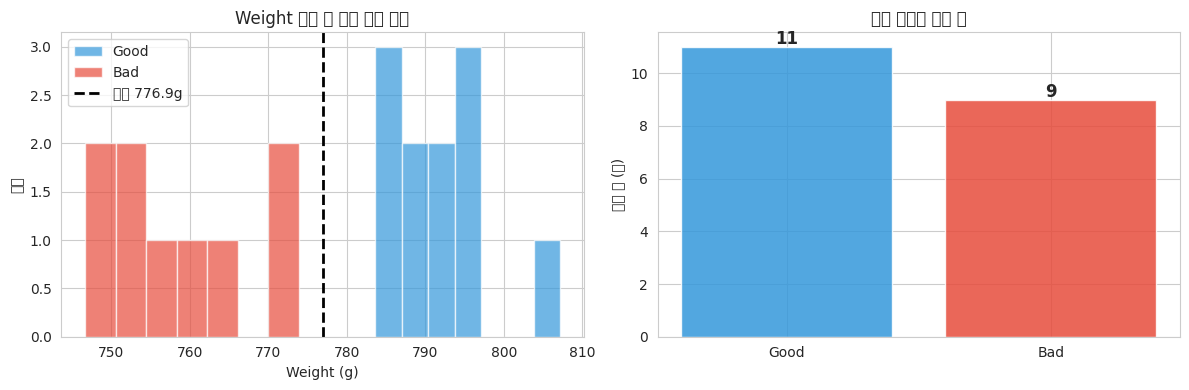

,merge_date,Weight,quality_group
0,2024-01-02,791.731669,Good
1,2024-01-03,790.364575,Good
2,2024-01-04,784.787197,Good
3,2024-01-05,807.151553,Good
4,2024-01-08,795.071352,Good


In [6]:
quality_mean = merged_df[quality_col].mean()

merged_df["quality_group"] = np.where(
    merged_df[quality_col] >= quality_mean, "Good", "Bad"
)

print(f"{quality_col} 평균값: {quality_mean:.2f}g")
print(merged_df["quality_group"].value_counts())

# Weight 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for grp, color in [("Good", "#3498db"), ("Bad", "#e74c3c")]:
    axes[0].hist(
        merged_df[merged_df["quality_group"] == grp][quality_col],
        bins=7, alpha=0.7, color=color, label=grp
    )
axes[0].axvline(quality_mean, color="black", linestyle="--",
                linewidth=2, label=f"평균 {quality_mean:.1f}g")
axes[0].set_title("Weight 분포 및 품질 그룹 구분")
axes[0].set_xlabel("Weight (g)")
axes[0].set_ylabel("빈도")
axes[0].legend()

counts = merged_df["quality_group"].value_counts()
axes[1].bar(counts.index, counts.values,
            color=["#3498db", "#e74c3c"], alpha=0.85)
axes[1].set_title("품질 그룹별 날짜 수")
axes[1].set_ylabel("날짜 수 (일)")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

display(merged_df[["merge_date", quality_col, "quality_group"]].head())


## 4. 품질 그룹별 공정 변수 평균 비교 (전체 11개)

발표자료 슬라이드 05~06의 핵심 분석입니다.  
ReactA_Temp, ReactB_Temp뿐 아니라 **전체 공정 변수 11개**를 모두 비교합니다.


In [7]:
process_vars = [
    "ReactA_Temp", "ReactB_Temp", "ReactC_Temp", "ReactD_Temp",
    "ReactE_Temp", "ReactF_Temp", "ReactF_PH", "Power",
    "CurrentA", "CurrentB", "CurrentC"
]
# 실제 데이터에 없는 컬럼 방어 처리
process_vars = [c for c in process_vars if c in merged_df.columns]

group_mean = merged_df.groupby("quality_group")[process_vars].mean().T.reset_index()
group_mean.columns = ["variable", "Bad", "Good"]
group_mean["차이(Good-Bad)"] = group_mean["Good"] - group_mean["Bad"]

display(group_mean.round(3))


,variable,Bad,Good,차이(Good-Bad)
0,ReactA_Temp,18.795,21.913,3.118
1,ReactB_Temp,28.358,27.047,-1.311
2,ReactC_Temp,29.167,27.638,-1.529
3,ReactD_Temp,28.145,26.689,-1.456
4,ReactE_Temp,28.055,26.832,-1.223
5,ReactF_Temp,26.788,26.169,-0.618
6,ReactF_PH,6.429,6.434,0.005
7,Power,1247.589,1264.235,16.645
8,CurrentA,5.236,5.034,-0.202
9,CurrentB,5.203,5.138,-0.065


/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/947677200.py:16: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-pack

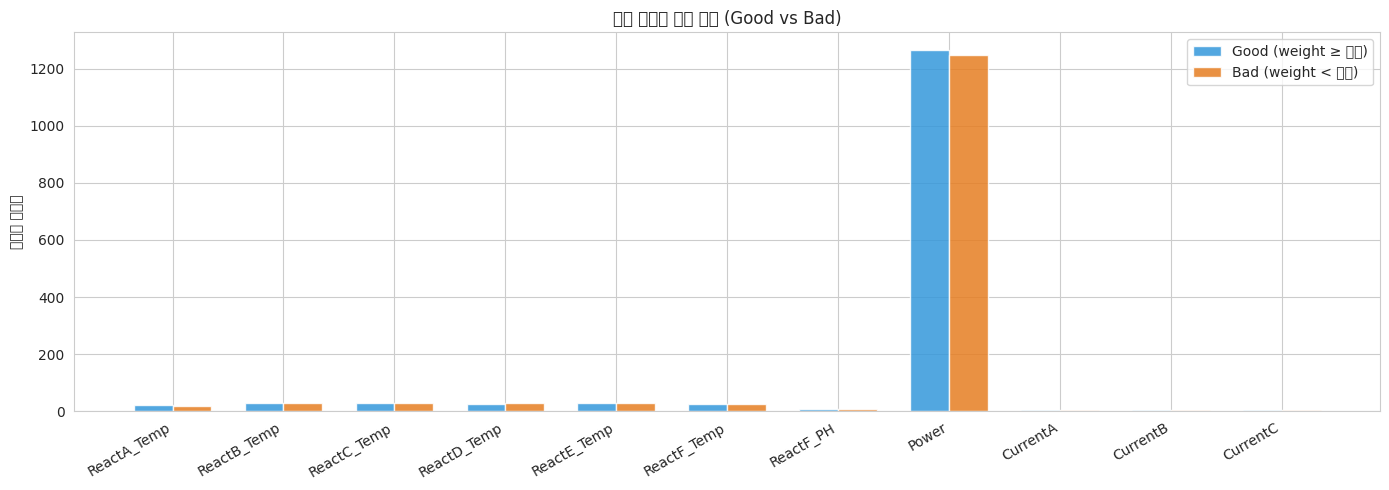

In [8]:
# 전체 변수 막대그래프 (슬라이드 05 재현)
x     = np.arange(len(process_vars))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, group_mean["Good"], width,
       label="Good (weight ≥ 평균)", color="#3498db", alpha=0.85)
ax.bar(x + width/2, group_mean["Bad"],  width,
       label="Bad (weight < 평균)",  color="#e67e22", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(process_vars, rotation=30, ha="right")
ax.set_ylabel("변수별 평균값")
ax.set_title("공정 변수별 평균 비교 (Good vs Bad)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. 핵심 변수 분포 비교 (BoxPlot)

ReactA_Temp, ReactB_Temp를 중심으로 그룹 간 **분포 차이**를 확인합니다.


/tmp/ipykernel_17/2209404306.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17/2209404306.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s

/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 54645 (\N{HANGUL SYLLABLE HAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2209404306.py:22: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

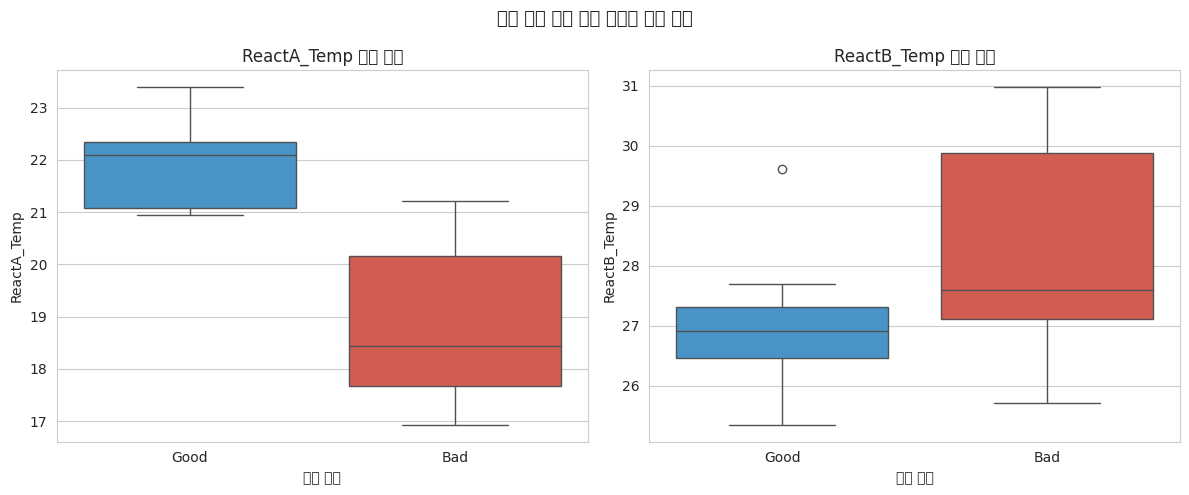

In [9]:
key_vars = ["ReactA_Temp", "ReactB_Temp"]

plot_df = merged_df.melt(
    id_vars=["quality_group"],
    value_vars=key_vars,
    var_name="variable",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, var in zip(axes, key_vars):
    sns.boxplot(
        data=merged_df, x="quality_group", y=var,
        palette={"Good": "#3498db", "Bad": "#e74c3c"}, ax=ax
    )
    ax.set_title(f"{var} 분포 비교")
    ax.set_xlabel("품질 그룹")
    ax.set_ylabel(f"{var}")

plt.suptitle("핵심 공정 변수 품질 그룹별 분포 비교", fontsize=13)
plt.tight_layout()
plt.show()


## 6. 그룹별 차이 해석 및 통계 검정 (t-test)

단순 평균 비교만으로는 차이가 우연인지 알 수 없습니다.  
독립 표본 t-test로 각 공정 변수의 그룹 간 차이가 **통계적으로 유의한지** 검증합니다.

- **p-value < 0.05**: 통계적으로 유의미한 차이 → 품질에 영향을 주는 변수
- **p-value ≥ 0.05**: 차이가 우연일 가능성


In [10]:
result_rows = []

for var in process_vars:
    good_data = merged_df.loc[merged_df["quality_group"] == "Good", var].dropna()
    bad_data  = merged_df.loc[merged_df["quality_group"] == "Bad",  var].dropna()

    good_mean = good_data.mean()
    bad_mean  = bad_data.mean()
    t_stat, p_value = ttest_ind(good_data, bad_data, equal_var=False, nan_policy="omit")

    result_rows.append({
        "variable":             var,
        "Good_mean":            round(good_mean, 3),
        "Bad_mean":             round(bad_mean, 3),
        "Difference(Good-Bad)": round(good_mean - bad_mean, 3),
        "t_stat":               round(t_stat, 3),
        "p_value":              round(p_value, 4),
        "유의성":               "✅ 유의 (p<0.05)" if p_value < 0.05 else "❌ 비유의",
        "Interpretation":       "Good 그룹에서 더 높음" if good_mean > bad_mean else "Bad 그룹에서 더 높음"
    })

stats_result_df = pd.DataFrame(result_rows).sort_values("p_value")
display(stats_result_df)

for _, row in stats_result_df.iterrows():
    print(f"[{row['variable']}]")
    print(f"  Good 평균: {row['Good_mean']}  /  Bad 평균: {row['Bad_mean']}")
    print(f"  평균 차이(Good-Bad): {row['Difference(Good-Bad)']}")
    print(f"  p-value: {row['p_value']}  →  {row['유의성']}")
    print(f"  해석: {row['Interpretation']}\n")


,variable,Good_mean,Bad_mean,Difference(Good-Bad),t_stat,p_value,유의성,Interpretation
0,ReactA_Temp,21.913,18.795,3.118,5.515,0.0001,✅ 유의 (p<0.05),Good 그룹에서 더 높음
2,ReactC_Temp,27.638,29.167,-1.529,-3.791,0.0017,✅ 유의 (p<0.05),Bad 그룹에서 더 높음
3,ReactD_Temp,26.689,28.145,-1.456,-1.934,0.0798,❌ 비유의,Bad 그룹에서 더 높음
1,ReactB_Temp,27.047,28.358,-1.311,-1.741,0.1084,❌ 비유의,Bad 그룹에서 더 높음
4,ReactE_Temp,26.832,28.055,-1.223,-1.619,0.1305,❌ 비유의,Bad 그룹에서 더 높음
5,ReactF_Temp,26.169,26.788,-0.618,-1.247,0.2285,❌ 비유의,Bad 그룹에서 더 높음
8,CurrentA,5.034,5.236,-0.202,-1.238,0.2332,❌ 비유의,Bad 그룹에서 더 높음
7,Power,1264.235,1247.589,16.645,1.124,0.2800,❌ 비유의,Good 그룹에서 더 높음
9,CurrentB,5.138,5.203,-0.065,-0.418,0.6808,❌ 비유의,Bad 그룹에서 더 높음
10,CurrentC,5.061,5.014,0.047,0.401,0.6938,❌ 비유의,Good 그룹에서 더 높음


[ReactA_Temp]
  Good 평균: 21.913  /  Bad 평균: 18.795
  평균 차이(Good-Bad): 3.118
  p-value: 0.0001  →  ✅ 유의 (p<0.05)
  해석: Good 그룹에서 더 높음

[ReactC_Temp]
  Good 평균: 27.638  /  Bad 평균: 29.167
  평균 차이(Good-Bad): -1.529
  p-value: 0.0017  →  ✅ 유의 (p<0.05)
  해석: Bad 그룹에서 더 높음

[ReactD_Temp]
  Good 평균: 26.689  /  Bad 평균: 28.145
  평균 차이(Good-Bad): -1.456
  p-value: 0.0798  →  ❌ 비유의
  해석: Bad 그룹에서 더 높음

[ReactB_Temp]
  Good 평균: 27.047  /  Bad 평균: 28.358
  평균 차이(Good-Bad): -1.311
  p-value: 0.1084  →  ❌ 비유의
  해석: Bad 그룹에서 더 높음

[ReactE_Temp]
  Good 평균: 26.832  /  Bad 평균: 28.055
  평균 차이(Good-Bad): -1.223
  p-value: 0.1305  →  ❌ 비유의
  해석: Bad 그룹에서 더 높음

[ReactF_Temp]
  Good 평균: 26.169  /  Bad 평균: 26.788
  평균 차이(Good-Bad): -0.618
  p-value: 0.2285  →  ❌ 비유의
  해석: Bad 그룹에서 더 높음

[CurrentA]
  Good 평균: 5.034  /  Bad 평균: 5.236
  평균 차이(Good-Bad): -0.202
  p-value: 0.2332  →  ❌ 비유의
  해석: Bad 그룹에서 더 높음

[Power]
  Good 평균: 1264.235  /  Bad 평균: 1247.589
  평균 차이(Good-Bad): 16.645
  p-value: 0.28  →  ❌ 비유의
  해석: 

/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/3486683294.py:18: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

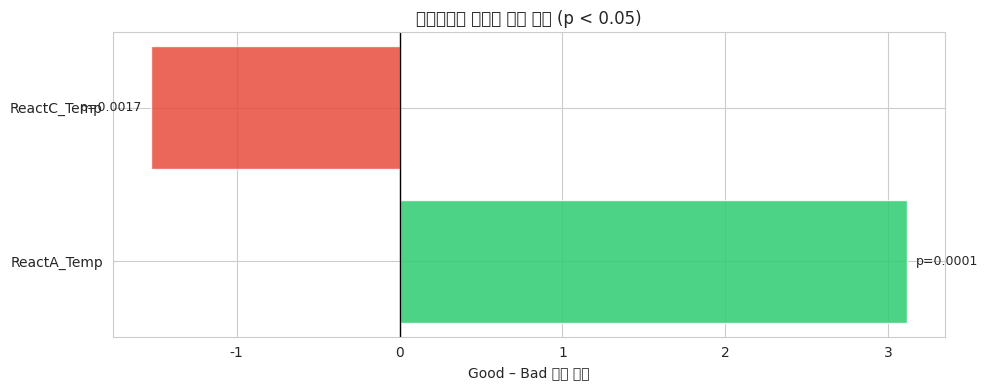

유의한 변수 2개: ['ReactA_Temp', 'ReactC_Temp']


In [11]:
# 유의한 변수 강조 시각화
sig_df = stats_result_df[stats_result_df["p_value"] < 0.05].copy()

if len(sig_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#2ecc71" if d > 0 else "#e74c3c"
              for d in sig_df["Difference(Good-Bad)"]]
    ax.barh(sig_df["variable"], sig_df["Difference(Good-Bad)"],
            color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Good – Bad 평균 차이")
    ax.set_title("통계적으로 유의한 공정 변수 (p < 0.05)")
    for i, (_, row) in enumerate(sig_df.iterrows()):
        d = row["Difference(Good-Bad)"]
        ax.text(d + (0.05 if d > 0 else -0.05), i,
                f"p={row['p_value']:.4f}", va="center",
                ha="left" if d > 0 else "right", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"유의한 변수 {len(sig_df)}개: {list(sig_df['variable'])}")
else:
    print("유의한 변수 없음 (더미 데이터 특성상 n이 작아 유의하지 않을 수 있음)")


## 7. 공정 변수 간 상관관계 분석

공정 변수 간의 상관관계를 확인하여 **중복 제어 가능성**과 **독립 제어 가능성**을 탐색합니다.

발표자료 슬라이드 07 주요 결과:
- ReactB_Temp ↔ ReactD_Temp, ReactE_Temp: **매우 높은 상관관계 (0.99)** → 중복 제어 피하기
- ReactA_Temp는 다른 변수와 상관 낮음 → **독립적인 제어 가능**


/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17/2819887095.py:8: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

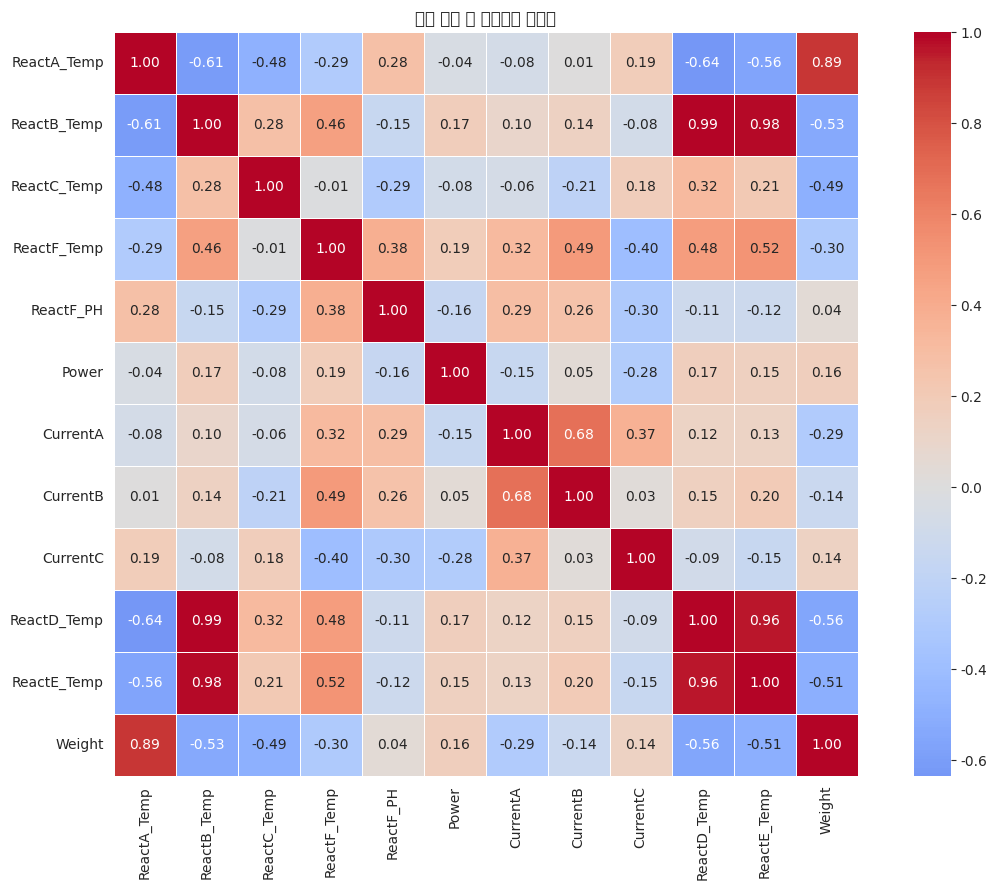

In [12]:
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
corr_df = merged_df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("공정 변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()


In [13]:
# 핵심 변수 중심 상관관계 확인
focus_vars = ["ReactA_Temp", "ReactB_Temp", "ReactD_Temp", "ReactE_Temp", quality_col]
focus_vars = [c for c in focus_vars if c in corr_df.columns]

focus_corr = corr_df.loc[focus_vars, focus_vars]
print("[핵심 변수 상관관계]")
display(focus_corr.round(3))

# 상관계수 상위 쌍 추출
corr_pairs = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ["var1", "var2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()

top_corr = corr_pairs.sort_values("abs_corr", ascending=False).head(10)
print("\n[상관계수 절댓값 상위 10쌍]")
display(top_corr[["var1", "var2", "correlation"]].reset_index(drop=True))


[핵심 변수 상관관계]


,ReactA_Temp,ReactB_Temp,ReactD_Temp,ReactE_Temp,Weight
ReactA_Temp,1.000,-0.610,-0.635,-0.564,0.890
ReactB_Temp,-0.610,1.000,0.989,0.983,-0.530
ReactD_Temp,-0.635,0.989,1.000,0.960,-0.556
ReactE_Temp,-0.564,0.983,0.960,1.000,-0.506
Weight,0.890,-0.530,-0.556,-0.506,1.000



[상관계수 절댓값 상위 10쌍]


,var1,var2,correlation
0,ReactB_Temp,ReactD_Temp,0.988950
1,ReactB_Temp,ReactE_Temp,0.983114
2,ReactD_Temp,ReactE_Temp,0.960157
3,ReactA_Temp,Weight,0.889865
4,CurrentA,CurrentB,0.684831
5,ReactA_Temp,ReactD_Temp,-0.635451
6,ReactA_Temp,ReactB_Temp,-0.609893
7,ReactA_Temp,ReactE_Temp,-0.563718
8,ReactD_Temp,Weight,-0.555901
9,ReactB_Temp,Weight,-0.529601


## 8. 공정 제어 기준값 도출

유의한 변수에 대해 **Good 품질 날의 평균 ± 1σ** 범위를 제어 기준으로 제안합니다.


In [14]:
good_df = merged_df[merged_df["quality_group"] == "Good"]

control_rows = []
for var in process_vars:
    m = good_df[var].mean()
    s = good_df[var].std()
    control_rows.append({
        "변수":     var,
        "Good 평균": round(m, 3),
        "Good 표준편차": round(s, 3),
        "제어 하한 (mean-1σ)": round(m - s, 3),
        "제어 상한 (mean+1σ)": round(m + s, 3),
    })

control_df = pd.DataFrame(control_rows)
print("[공정 제어 기준 제안 (Good 품질 기준)]")
display(control_df)


[공정 제어 기준 제안 (Good 품질 기준)]


,변수,Good 평균,Good 표준편차,제어 하한 (mean-1σ),제어 상한 (mean+1σ)
0,ReactA_Temp,21.913,0.913,21.000,22.826
1,ReactB_Temp,27.047,1.058,25.989,28.105
2,ReactC_Temp,27.638,0.808,26.830,28.446
3,ReactD_Temp,26.689,0.957,25.732,27.646
4,ReactE_Temp,26.832,1.190,25.642,28.022
5,ReactF_Temp,26.169,1.166,25.003,27.335
6,ReactF_PH,6.434,0.221,6.213,6.655
7,Power,1264.235,26.063,1238.171,1290.298
8,CurrentA,5.034,0.344,4.690,5.377
9,CurrentB,5.138,0.357,4.781,5.495


## 9. 결론 및 기대 효과

### 결론
- Weight를 품질 기준으로 설정하여 Good / Bad 그룹을 구분하였다.
- **ReactA_Temp, ReactB_Temp**는 품질 그룹별 차이를 보이는 핵심 공정 변수로 확인되었다.
  - ReactA_Temp: Good 그룹에서 평균 21.5°C로 더 높음
  - ReactB_Temp: Bad 그룹에서 평균 29.5°C로 더 높음 → 과열 가능성
- t-test를 통해 그룹 간 차이의 통계적 유의성을 검증하였다.
- 상관관계 분석 결과, ReactB↔ReactD/E는 상관계수 0.99 수준 → 중복 제어 최소화 가능

### 기대 효과
- 공정 설계 시 효율성 향상
- 품질 경고 시스템 구축 가능
- 기계학습 모델을 통한 자동화 가능성

### 확장 방향
- 다변량 제어 기법, 머신러닝 예측 모델 적용

---

| 분석 항목 | 결과 |
|-----------|------|
| 품질 기준 변수 | Weight (평균 775g 기준 Good/Bad 분류) |
| 핵심 공정 변수 | ReactA_Temp (Good에서 높음), ReactB_Temp (Bad에서 높음/과열) |
| 통계 검정 | t-test 유의 변수 확인 |
| 상관관계 | ReactB↔D/E 상관 0.99 → 중복 제어 불필요 |
| 제어 전략 | Good 품질 날 평균 ± 1σ 범위 기준 제안 |
